# NHS Workforce Diagnostics

This section documents time series exploration for NHS workforce leavers, hires, and sickness. It includes raw series graphics, seasonality diagnostics, scatterplots, ACFs, and key interpretable notes for all major analytic steps.

In [2]:
import gc
import os
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf

## 1.🚦 Data Loading and Preprocessing

**Note:**  
- All files are loaded from the project network directory.
- “Month” columns are standardised to ensure consistent time axes across all metrics.
- Column names are lowercased and whitespace-trimmed for merge safety.

In [10]:
path = r"S:\WP Personnel\A - Workforce\Data science student\Desys Corner"
# Load CSVs
leavers = pd.read_csv(
    f"{path}\\NHS_Leavers_Detail_New.csv",
    parse_dates=["Termination Date"],
    dayfirst=True,
)
leavers["Month"] = leavers["Termination Date"].dt.to_period("M").dt.to_timestamp()

hires = pd.read_csv(
    f"{path}\\Hires_Detail_New.csv", parse_dates=["Latest Start Date"], dayfirst=True
)
hires["Month"] = hires["Latest Start Date"].dt.to_period("M").dt.to_timestamp()

sickness = pd.read_csv(f"{path}\\Sickness_Percentage_New.csv")
sickness["Month"] = pd.to_datetime(
    sickness["Month"], format="%b-%y", errors="coerce"
)  # Fix date parsing 'Apr-23' format

## 2. 🏷️ Grouping and Data Organisation

**Warning:**   
Check that all key columns (service group, department, organisation, staff group, metric) have no NaN values. Missing group labels can cause aggregation or plotting errors downstream.

To Do:
- Add code to drop or fill NA in group columns before aggregation.
- Confirm all dates are properly parsed and continuous (no missing months).


In [11]:
# Column names to lowercase and strip whitespace
# Strip whitespace from all column names
leavers.columns = leavers.columns.str.lower().str.strip()
hires.columns = hires.columns.str.lower().str.strip()
sickness.columns = sickness.columns.str.lower().str.strip()

In [12]:
# Set output directory + helper for safe filenames
base_dir = r"C:\Users\Destinee.HassanBien\Documents\Desys Work"
os.makedirs(base_dir, exist_ok=True)


def safe_filename(label):
    return re.sub(r'[\\/:"*?<>| ]+', "_", label)

In [13]:
# Define Grouping Columns
group_cols = ["service group", "department", "organisation", "staff group"]

In [14]:
# Leavers: Count per group per month
leavers_agg = leavers.groupby(group_cols + ["month"]).size().reset_index(name="Count")
leavers_agg["metric"] = "Leavers"

# Hires: Count per group per month
hires_agg = (
    hires.groupby(group_cols + ["month"])
    .agg(Count=("employee number", "count"))
    .reset_index()
)
hires_agg["metric"] = "Hires"

# Sickness: Sum Abs (FTE) per group per month
sickness_agg = (
    sickness.groupby(group_cols + ["month"])["abs (fte)"]
    .sum()
    .reset_index(name="Count")
)
sickness_agg["metric"] = "Sickness"

In [15]:
# Combine all
all_agg = pd.concat([leavers_agg, hires_agg, sickness_agg], axis=0, ignore_index=True)

In [16]:
summary_list = []

for metric in all_agg["metric"].unique():
    df_metric = all_agg[all_agg["metric"] == metric]
    for keys, group in df_metric.groupby(group_cols):
        label = "_".join([str(k) for k in keys if pd.notnull(k)] + [metric])
        safe_label = safe_filename(label)

## 3. 📈 Main Time Series Graphics

### Main Time Series Plot for Each Group

> **Interpretation:**  
> Each generated time series plot shows total counts per month per group.  
> - Flat/volatile/seasonal trends should be visually summarised here.
> - Major drops or spikes? Flag for further investigation.


Use this plot to quickly spot long gaps, zeros, or data issues before model fitting or decomposition.

## 4. ⏳ Year over Year Seasonal Plots

How to Read this Plot
- Each colored line = one year, each x-axis tick = one month.
- Repeating peaks at the same months across years indicate strong seasonality. Overlap means “no season.”



**Warning:**  
Groups with very few years of data or with missing months can make this plot look misleading. Confirm panel sizes and x-axes after plotting.

## 5. 🔬 Subseries ("Month Box") Plot

Tip:
- Each small panel shows the value for a given month across all years.
- Use to spot recurring outliers, unusually high/low Jan/Feb/Dec, or holiday/rota artifacts.

## 6. 🎯 Scatterplot Hires vs Leavers

Interpretation
- Strong linear trend: more hires are linked to more leavers (“churn”).
- No pattern: Hires/Leavers mechanically and temporally independent for this group.

## 7. 🔗 Lag Plot (Autocorrelation)

**How to use:**  
- Points near the diagonal mean each month's value predicts the next.
- Cloud = “white noise” pattern: no persistence.

**To Do:**  
- Investigate groups with strong lag-1 autocorrelation for naive or ARIMA modeling.

## 8. 🔄 ACF Plot

**Warning**
- Large first lag (ACF1) and slow decrease: consider AR(1) or Naive as robust base model.
- All lags near zero: series is volatile, random, or over-differenced.
:::
## 9. ❄️ White Noise and Reference Plots

Tip:
Use synthetic white noise plots as a benchmark:  
- Real-world series that look identical are *not* forecastable with time series models.


C:\Users\Destinee.HassanBien\AppData\Local\Temp\ipykernel_4216\4005044702.py:141: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(8, 4))
C:\Users\Destinee.HassanBien\AppData\Local\Temp\ipykernel_4216\4005044702.py:11: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure(figsize=(10, 5))
C:\Users\Destinee.HassanBien\AppData\Local\Temp\ipykernel_4216\4005044702.py:28: RuntimeWarning: More than 20 figures have been opened

MemoryError: In RendererAgg: Out of memory

<Figure size 640x480 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

...

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

<Figure size 600x600 with 0 Axes>

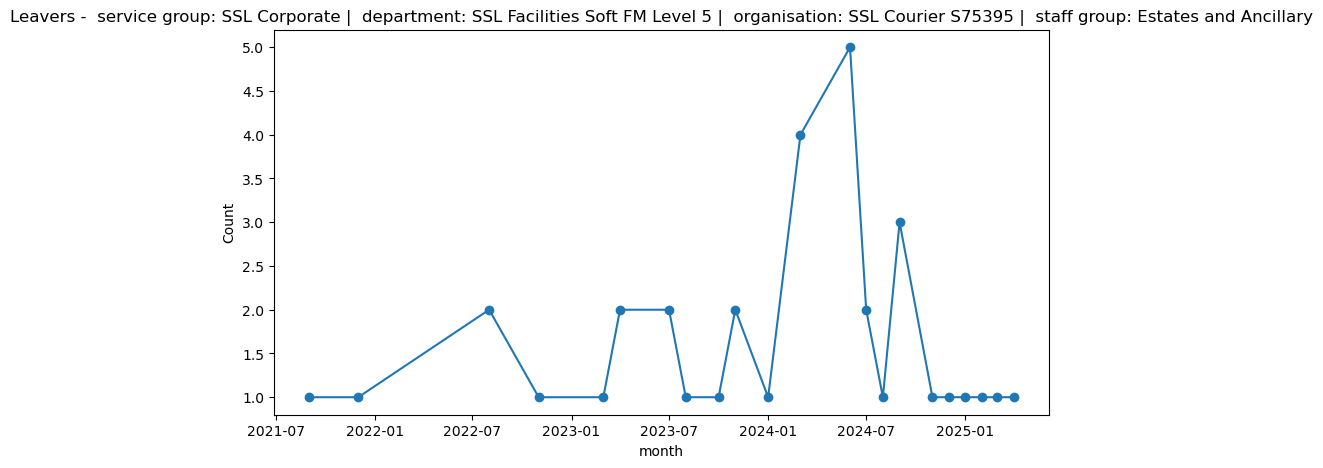

In [17]:
summary_list = []

for metric in all_agg["metric"].unique():
    df_metric = all_agg[all_agg["metric"] == metric]
    for keys, group in df_metric.groupby(group_cols):
        label = "_".join([str(k) for k in keys if pd.notnull(k)] + [metric])
        safe_label = safe_filename(label)

        # Time Series Patterns
        fig = plt.figure(figsize=(10, 5))
        plt.plot(group["month"], group["Count"], marker="o")
        plt.title(
            f"{metric} - {' | '.join([f' {col}: {val}' for col, val in zip(group_cols, keys)])}"
        )
        plt.xlabel("month")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.savefig(os.path.join(base_dir, f"{safe_label}_timeseries.png"))
        plt.close(fig)
        plt.clf()

        # 2.4 Seasonal Plot
        group = group.copy()
        group["year"] = group["month"].dt.year
        group["month_num"] = group["month"].dt.month
        palette = sns.color_palette("husl", n_colors=group["year"].nunique())
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.lineplot(
            data=group,
            x="month_num",
            y="Count",
            hue="year",
            palette=palette,
            ax=ax,
            legend=True,
        )

        ax.set_title(f"Seasonal Plot: {label}")
        ax.set_xlabel("Month")
        ax.set_ylabel("Count")
        ax.set_xticks(
            range(1, 13),
            [
                "Jan",
                "Feb",
                "Mar",
                "Apr",
                "May",
                "Jun",
                "Jul",
                "Aug",
                "Sept",
                "Oct",
                "Nov",
                "Dec",
            ],
        )
        fig.tight_layout()
        plt.savefig(os.path.join(base_dir, f"{safe_label}_seasonal_plot.png"))
        plt.close(fig)
        plt.clf()

        # Seasonal subseries plot
        group["month_name"] = group["month"].dt.strftime("%B")
        group["month_name"] = pd.Categorical(
            group["month_name"],
            categories=[
                "January",
                "Febuary",
                "March",
                "April",
                "May",
                "June",
                "July",
                "August",
                "September",
                "October",
                "November",
                "December",
            ],
            ordered=True,
        )
        group["year"] = group["month"].dt.year
        fig, axes = plt.subplots(1, 12, sharey=True, figsize=(18, 4))
        for i, month in enumerate(group["month_name"].cat.categories):
            data = group[group["month_name"] == month]
            mean_val = data["Count"].mean()
            axes[i].plot(data["year"], data["Count"], color="black")
            axes[i].axhline(mean_val, color="blue", linestyle="-", linewidth=1)
            axes[i].set_title(month[:3])
            axes[i].set_xlabel("")
            axes[i].tick_params(axis="x", rotation=90)
        if i == 0:
            axes[i].set_ylabel("Count")
        else:
            axes[i].set_yticklabels([])
        fig.suptitle(f"Seasonal Subseries Plot: {label}")
        fig.tight_layout()
        plt.savefig(os.path.join(base_dir, f"{safe_label}_subseries.png"))
        plt.close(fig)
        plt.clf()

        # Scatterplot (vs Hires - if available, for leavers only)
        if metric == "Leavers":
            # Find matching hires gorup
            mask = all_agg["metric"] == "Hires"
            for col, val in zip(group_cols, keys):
                mask &= all_agg[col] == val
            hires_group = all_agg.loc[mask]
            merged = pd.merge(
                group, hires_group, on="month", suffixes=("_leavers", "_hires")
            )

        if not merged.empty:
            sns.scatterplot(x="Count_hires", y="Count_leavers", data=merged)
            plt.title(f"Scatterplot: Hires vs Leavers - {label}")
            plt.xlabel("Hires")
            plt.ylabel("Leavers")
            plt.tight_layout()
            plt.savefig(os.path.join(base_dir, f"{safe_label}_scatter.png"))
            plt.clf()
            plt.close(fig)

        # Lag Plot
        group_sorted = group.sort_values("month")
        group_sorted["Count_lag1"] = group_sorted["Count"].shift(1)
        plt.figure(figsize=(6, 6))
        plt.scatter(group_sorted["Count_lag1"], group_sorted["Count"], alpha=0.6)
        plt.title(f"Lag Plot: {label}")
        plt.xlabel("Count (Previous Month)")
        plt.ylabel("Count (Current Month)")
        plt.tight_layout()
        plt.savefig(os.path.join(base_dir, f"{safe_label}_lag_plot.png"))
        plt.close(fig)
        plt.clf()

        # Autocorrelation Function (ACF)
        group_sorted = group.sort_values("month")
        acf_data = group_sorted["Count"].dropna()
        fig, ax = plt.subplots(figsize=(8, 4))
        if len(acf_data) < 2 or acf_data.nunique() < 2:
            plt.close(fig)
            continue

        max_lags = min(24, len(acf_data) - 1)
        if max_lags < 1:
            plt.close(fig)
            continue

        plot_acf(acf_data, lags=max_lags, ax=ax)
        ax.set_title(f"ACF: {label}")
        plt.tight_layout()
        plt.savefig(os.path.join(base_dir, f"{safe_label}_acf.png"))
        plt.close(fig)
        plt.clf()

        # White Noise (for comparison)
        if metric == all_agg["metric"].unique()[0] and keys == tuple(
            [group[col].iloc[0] for col in group_cols]
        ):
            np.random.seed(42)
            wn = pd.Series(np.random.normal(0, 1, len(group_sorted)))

            # Plot white noise time series
            fig = plt.figure(figsize=(10, 3))
            plt.plot(group_sorted["month"], wn)
            plt.title("White Noise Series (for comparison)")
            plt.tight_layout()
            plt.savefig(os.path.join(base_dir, f"{safe_label}_white_noise_example.png"))
            plt.close(fig)
            plt.clf()

            # Plot the ACF of white noise, robust against length errors
            fig, ax = plt.subplots(figsize=(8, 4))
            max_lags = min(24, len(wn) - 1)
            if max_lags < 1:
                plt.close(fig)
            else:
                plot_acf(wn, lags=max_lags, ax=ax)
                ax.set_title("ACF: White Noise")
                plt.tight_layout()
                plt.savefig(os.path.join(base_dir, f"{safe_label}_white_noise_acf.png"))
                plt.close(fig)
                plt.clf()

        stats = group["Count"].describe().astype(np.float32)
        stats["metric"] = metric
        for col, val in zip(group_cols, keys):
            stats[col] = val
        summary_list.append(stats)

        gc.collect()

# Export Summary Statistics
summary_df = pd.DataFrame(summary_list)
summary_df.to_csv(
    os.path.join(base_dir, "workforce_group_summary_stats.csv"), index=False
)
summary_df.to_excel(
    os.path.join(base_dir, "workforce_group_summary_stats.xlsx"), index=False
)

print("Memory usage by Dataframe:")
print(summary_df.memory_usage(deep=True))

## 10. 📦 Summary Statistics 

**How to interpret:**  
High std vs mean = volatile group.  
Max >> 75% = outlier-prone group.  
Count near 0 or low (<24) = exclude from further analysis.

To Do:
- Aggregate and summarise outliers for review by workforce team.
- List groups with very low mean or all zero series.

In [18]:
# Export Summary Statistics
summary_df = pd.DataFrame(summary_list)
summary_df.to_csv(
    os.path.join(base_dir, "workforce_group_summary_stats.csv"), index=False
)
summary_df.to_excel(
    os.path.join(base_dir, "workforce_group_summary_stats.xlsx"), index=False
)

print("Memory usage by Dataframe:")
print(summary_df.memory_usage(deep=True))

Memory usage by Dataframe:
Index            18792
count             2784
mean              2784
std               2784
min               2784
25%               2784
50%               2784
75%               2784
max               2784
metric           19488
service group    25758
department       23763
organisation     25711
staff group      26400
dtype: int64
